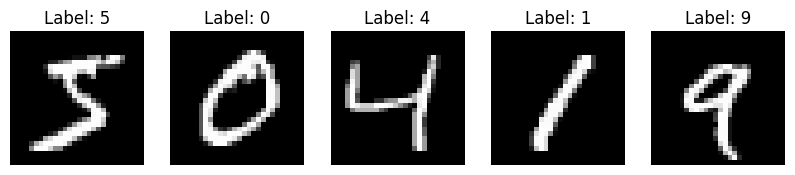

12000
Frecuencia de números: {0: 1184, 1: 1348, 2: 1191, 3: 1227, 4: 1169, 5: 1085, 6: 1183, 7: 1253, 8: 1170, 9: 1190}
Primeros ejemplos (labels): [5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1]
12000
Frecuencia de números: {0: 1185, 1: 1349, 2: 1191, 3: 1226, 4: 1168, 5: 1084, 6: 1184, 7: 1253, 8: 1170, 9: 1190}
Primeros ejemplos (labels): [7, 7, 7, 7, 7, 7, 6, 7, 7, 6, 6, 7, 0, 7, 6]
12000
Frecuencia de números: {0: 1185, 1: 1349, 2: 1192, 3: 1226, 4: 1168, 5: 1084, 6: 1184, 7: 1253, 8: 1170, 9: 1189}
Primeros ejemplos (labels): [3, 3, 3, 3, 9, 3, 9, 9, 3, 3, 3, 9, 9, 1, 9]
12000
Frecuencia de números: {0: 1185, 1: 1348, 2: 1192, 3: 1226, 4: 1168, 5: 1084, 6: 1184, 7: 1253, 8: 1170, 9: 1190}
Primeros ejemplos (labels): [1, 1, 1, 1, 1, 9, 1, 1, 1, 1, 9, 9, 9, 1, 9]
12000
Frecuencia de números: {0: 1184, 1: 1348, 2: 1192, 3: 1226, 4: 1169, 5: 1084, 6: 1183, 7: 1253, 8: 1171, 9: 1190}
Primeros ejemplos (labels): [1, 1, 1, 1, 1, 1, 1, 1, 1, 9, 1, 9, 1, 1, 1]


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from tensorflow import keras

train, test = keras.datasets.mnist.load_data()

x_train, x_test = np.expand_dims(train[0] / 255.0, -1), np.expand_dims(test[0] / 255.0, -1)
y_train, y_test = train[1], test[1]

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.show()

skf = StratifiedKFold(n_splits=5)

folds = skf.split(x_train, y_train)

local_data = [(x_train[tsix], y_train[tsix]) for trix, tsix in folds]

for x in local_data:
    print(len(x[0]))
    print(f"Frecuencia de números: { {int(y):list(x[1]).count(y) for y in set(x[1])} }")
    print(f"Primeros ejemplos (labels): {[int(y) for y in list(x[1])[:15]]}")

In [2]:
import json
for i, (x_part, y_part) in enumerate(local_data):
    json_data = {"x": x_part.tolist(), "y": y_part.tolist()}  

    with open(f"data_part_{i}.json", "w") as f:
        json.dump(json_data, f, indent=4)



OSError: [Errno 28] No space left on device